We consider a simple Cournot-style bilevel instance with a scalar leader decision $x\in[-R_x,R_x]$ and $k$ followers choosing quantities
$$y=(y_1,\dots,y_k)\in[0,R_y]^k.$$

The leader (regulator) controls a single scalar policy lever $x\in [-R_x, R_x]$ which represents a per-unite subsidy (if $x > 0$) or tax (if $x < 0$) applied uniformly to a homogeneous industry. The market consists of $k$ identical firms (the followers). Each firm $i$ chooses an output level $y_i\in [0, R_y]$ each period.

The policy shifts the firm’s per-unit incentive linearly by $a+x$ per unit produced. The cost of production is $\frac{c}{2}y_i^2$. Thus, each firm's objective is to minimize the total cost:
$$g_i(x,y)=\frac{c}{2}y_i^2-(a+x-bQ)y_i,\qquad i=1,\dots,k,$$
where $Q = \sum_{i=1}^k y_i$, so the follower subgame is a (k)-player strongly monotone game with a unique equilibrium
$$
y_i^*(x)=\Pi_{[0,R_y]}\left(\frac{a+x}{c+b(k+1)}\right),\qquad Q^*(y)=\sum_{i=1}^k y_i^*(x).
$$
The regulator objective is to hit a desired total production target $Q_{des}$ while avoiding extreme polities. Together, the regulator wants to minimize

$$
f(x,y)=\frac{\mu_x}{2}x^2+\frac{\gamma}{2}\bigg(\sum_{i=1}^k y_i-Q_{\mathrm{des}}\bigg)^2,
$$

and the true bilevel objective is $F(x)=f(x,y^*(x))$.

In this example, the surrogate gradient has the closed form
$$
\nabla_x \tilde L_{\lambda}(x,y,z)
=\mu_x x+\lambda(Q(z)-Q(y)),
$$
since $\nabla_x g_i(x,\cdot)=-y_i$. Empirically, the experiment shows that $|\nabla F(x_t)|$ decreases to near zero and the optimality gap $F(x_t)-F(x^\star)$ decays to (numerical) zero, while the inner errors $|z_{t+1}-z^*(x_t)|$ and $|y_{t+1}-z^*(x_t)|$ simultaneously shrink. This behavior is consistent with the paper’s guarantees: the increasing penalty and improved inner accuracy make the surrogate gradient $\nabla_x \tilde L_{\lambda_t}$ a reliable proxy for $\nabla F$, so the outer iterate converges toward a stationary point (here the unique minimizer) of the bilevel objective.

In the experiment, we choose $a = 12, b = 1, c = 2, k = 5, R_x = R_y = 10, \mu_x = 3, \gamma = 1, Q_{des} = 10$



## First-order method


x* ≈ 0.1208459039839983
final x_hat = 0.12083793834901728 gap = 3.1935343258737703e-10 |∇F| = 8.000365625848715e-05
min gap = 3.1935343258737703e-10 at t 1500
first t with gap<=1e-6: 1128


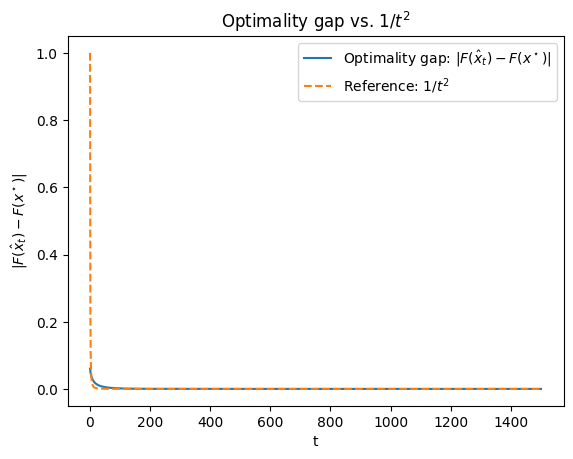

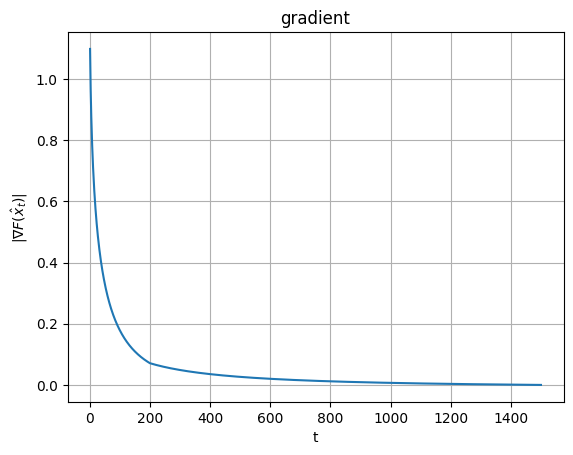

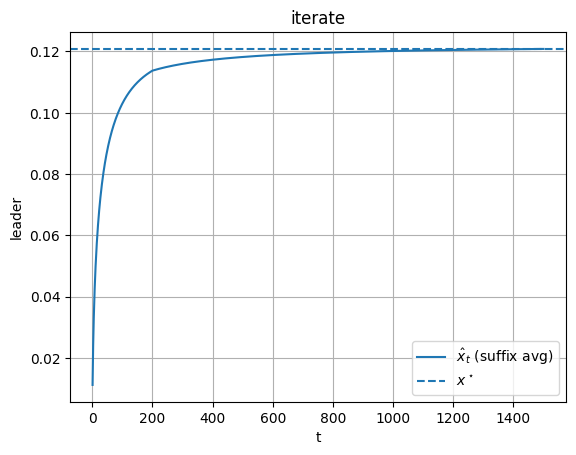

In [ ]:
import numpy as np, math, matplotlib.pyplot as plt

# ===== Cournot instance =====
a=12; b=0.1; c=20; k=3
Rx=10; Ry=100
mu_x=10; gamma=1; Qdes=10
den=c+b*(k+1)

def proj(v, lo, hi): return np.minimum(np.maximum(v, lo), hi)
def y_star(x): return np.ones(k)*proj((a+x)/den, 0, Ry)
def F(x):
    y=y_star(x); Q=y.sum()
    return 0.5*mu_x*x*x + 0.5*gamma*(Q-Qdes)**2
def grad_F(x):
    y_un=(a+x)/den
    if y_un<=0 or y_un>=Ry: return mu_x*x
    Q=k*y_un; dQdx=k/den
    return mu_x*x + gamma*(Q-Qdes)*dQdx

def golden_min(f,a0,b0,tol=1e-14,maxit=4000):
    gr=(math.sqrt(5)-1)/2
    a_=a0; b_=b0
    c_=b_-gr*(b_-a_); d_=a_+gr*(b_-a_)
    fc=f(c_); fd=f(d_)
    for _ in range(maxit):
        if abs(b_-a_)<tol: break
        if fc<fd:
            b_=d_; d_=c_; fd=fc
            c_=b_-gr*(b_-a_); fc=f(c_)
        else:
            a_=c_; c_=d_; fc=fd
            d_=a_+gr*(b_-a_); fd=f(d_)
    x_=(a_+b_)/2
    return x_, f(x_)
x_star, F_star = golden_min(F, -Rx, Rx)

def Mz_schedule(t, base=85, grow=8):
    return int(base + grow*math.log(t+1))

def My_schedule(t, base=125, grow=10):
    return int(base + grow*math.log(t+1))

# ===== AOG z-inner =====
def V_op(y,x):
    Q=y.sum()
    return (c+b)*y + b*Q*np.ones(k) - (a+x)*np.ones(k)

L_g=c+b+b*k
eta_aog=1.0/(3.0*L_g)  # fileciteturn1file0

def solve_game_z_aog(x,z_init,M):
    z=z_init.copy(); z_anchor=z_init.copy(); z_half_prev=z.copy()
    for m in range(1,M+1):
        alpha=1.0/(m+1.0)
        z_half=proj(z - eta_aog*V_op(z_half_prev,x) + alpha*(z_anchor-z), 0, Ry)
        z_next=proj(z - eta_aog*V_op(z_half,x) + alpha*(z_anchor-z), 0, Ry)
        z, z_half_prev = z_next, z_half
    return z

# y-inner PGD (accurate enough)
def grad_y_Ltilde(x,y,z,lam):
    Qy=y.sum(); Qz=z.sum()
    common = gamma*(Qy - Qdes)
    Q_minus = Qz - z
    return common + lam*((c+2*b)*y - (a + x - b*Q_minus))

def solve_y_pg_fixed(x,y0,z,lam,M):
    L = lam*(c+2*b) + gamma*k
    eta = 1.0/L
    y=y0.copy()
    for _ in range(M):
        y = proj(y - eta*grad_y_Ltilde(x,y,z,lam), 0, Ry)
    return y

def grad_x_surrogate(x,y,z,lam):
    return mu_x*x + lam*(z.sum()-y.sum())

def run_suffix_avg(T=1000, rho=1.2, eta0=0.01, eta_decay=0.5, x0=0.0,
                   avg_start=150):
    x=float(x0)
    z=np.zeros(k); y=np.zeros(k)
    xhat=float(x0); n=0
    xhats=np.zeros(T); grads=np.zeros(T); gaps=np.zeros(T)
    for t in range(1,T+1):
        lam=t**rho
        Mz=Mz_schedule(t)
        My=My_schedule(t)
        z=solve_game_z_aog(x,z,Mz)
        y=solve_y_pg_fixed(x,y,z,lam,My)
        eta_t=eta0/(t**eta_decay)
        x=proj(x - eta_t*grad_x_surrogate(x,y,z,lam), -Rx, Rx)
        if t>=avg_start:
            n += 1
            xhat = xhat + (x - xhat)/n
        else:
            xhat = x
        xhats[t-1]=xhat
        grads[t-1]=abs(grad_F(xhat))
        gaps[t-1]=abs(F(xhat)-F_star)
    return xhats, grads, gaps

T=1500
xhats, grads_hat, gaps_hat = run_suffix_avg(T=T, avg_start=200)

t=np.arange(1,T+1)
hit = np.where(gaps_hat<=1e-6)[0]
print("x* ≈", x_star)
print("final x_hat =", xhats[-1], "gap =", gaps_hat[-1], "|∇F| =", grads_hat[-1])
print("min gap =", gaps_hat.min(), "at t", int(gaps_hat.argmin()+1))
print("first t with gap<=1e-6:", int(hit[0]+1) if len(hit)>0 else None)
#print("Average time per iteration =", np.mean(elapsed_time))

plt.figure()
plt.plot(t, gaps_hat, label=r'Optimality gap: $|F(\hat x_t)-F(x^\star)|$')

# reference curve y = 1/t^2
t_arr = np.asarray(t, dtype=float)
plt.plot(t_arr, 1.0 / (t_arr**2), '--', label=r'Reference: $1/t^2$')

plt.xscale('linear')
plt.yscale('linear')
plt.xlabel('t')
plt.ylabel(r'$|F(\hat x_t)-F(x^\star)|$')
plt.title('Optimality gap vs. $1/t^2$')
plt.legend()
#plt.grid(True, which='both')


plt.figure()
plt.plot(t, grads_hat)
#plt.yscale('log')
plt.xlabel('t')
plt.ylabel(r'$|\nabla F(\hat x_t)|$')
plt.title('gradient')
plt.grid(True, which='both')

plt.figure()
plt.plot(t, xhats, label=r'$\hat x_t$ (suffix avg)')
plt.axhline(x_star, linestyle='--', label=r'$x^\star$')
plt.xlabel('t'); plt.ylabel('leader')
plt.title('iterate')
plt.grid(True, which='both'); plt.legend()
plt.show()



x* ≈ -0.16962171843264284
F(x* = ) 1.6113639196804974
final x_hat = -0.1699936963967965 gap = 7.59657969418015e-07 |∇F| = 0.004084424559907207
min gap = 7.390310585719817e-12 at t 538
first t with gap<=1e-6: 486
Average time per iteration = 0.05561169266700745
Time to converges =  32.03712463378906


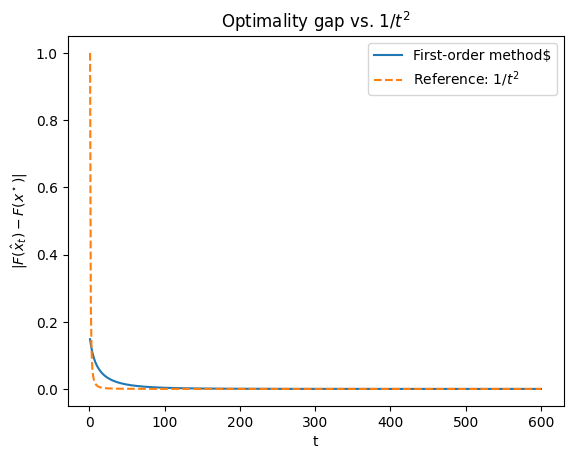

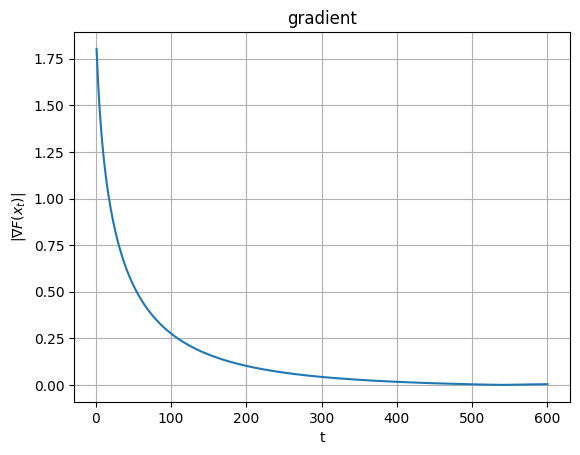

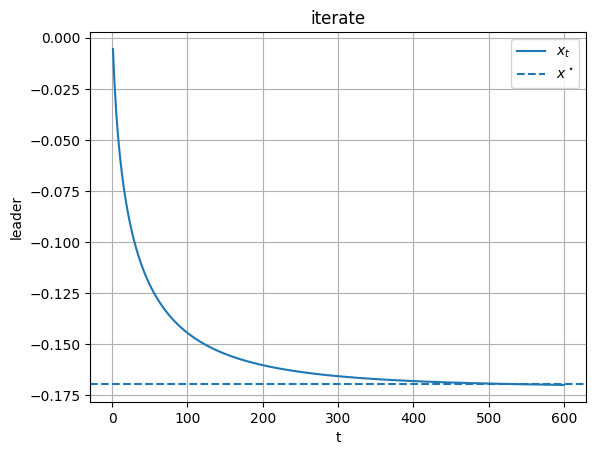

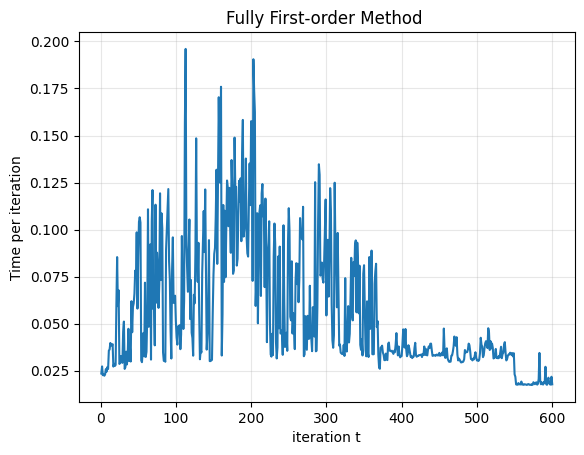

In [ ]:
import numpy as np, math, matplotlib.pyplot as plt
import time

# ===== Cournot instance =====
a=12; b=0.01; c=2000; k=2000
Rx=100; Ry=1000
mu_x=10; gamma=1; Qdes=10
den=c+b*(k+1)

def proj(v, lo, hi): return np.minimum(np.maximum(v, lo), hi)
def y_star(x): return np.ones(k)*proj((a+x)/den, 0, Ry)
def F(x):
    y=y_star(x); Q=y.sum()
    return 0.5*mu_x*x*x + 0.5*gamma*(Q-Qdes)**2
def grad_F(x):
    y_un=(a+x)/den
    if y_un<=0 or y_un>=Ry: return mu_x*x
    Q=k*y_un; dQdx=k/den
    return mu_x*x + gamma*(Q-Qdes)*dQdx

# def golden_min(f,a0,b0,tol=1e-14,maxit=4000):
#     gr=(math.sqrt(5)-1)/2
#     a_=a0; b_=b0
#     c_=b_-gr*(b_-a_); d_=a_+gr*(b_-a_)
#     fc=f(c_); fd=f(d_)
#     for _ in range(maxit):
#         if abs(b_-a_)<tol: break
#         if fc<fd:
#             b_=d_; d_=c_; fd=fc
#             c_=b_-gr*(b_-a_); fc=f(c_)
#         else:
#             a_=c_; c_=d_; fc=fd
#             d_=a_+gr*(b_-a_); fd=f(d_)
#     x_=(a_+b_)/2
#     return x_, f(x_)
# x_star, F_star = golden_min(F, -Rx, Rx)

denom = c + b * (k + 1.0)
A = mu_x + gamma * (k / denom) ** 2
B = gamma * (k / denom) * (k * a / denom - Qdes)
x_star = float(np.clip(-B/A, -Rx, Rx))
F_star = F(x_star)


def Mz_schedule(t, base=85, grow=8):
    return int(base + grow*math.log(t+1))

def My_schedule(t, base=125, grow=10):
    return int(base + grow*math.log(t+1))

# ===== AOG z-inner =====
def V_op(y,x):
    Q=y.sum()
    return (c+b)*y + b*Q*np.ones(k) - (a+x)*np.ones(k)

L_g=c+b+b*k
eta_aog=1.0/(3.0*L_g)  # fileciteturn1file0

def solve_game_z_aog(x,z_init,M):
    z=z_init.copy(); z_anchor=z_init.copy(); z_half_prev=z.copy()
    for m in range(1,M+1):
        alpha=1.0/(m+1.0)
        z_half=proj(z - eta_aog*V_op(z_half_prev,x) + alpha*(z_anchor-z), 0, Ry)
        z_next=proj(z - eta_aog*V_op(z_half,x) + alpha*(z_anchor-z), 0, Ry)
        z, z_half_prev = z_next, z_half
    return z

# y-inner PGD (accurate enough)
def grad_y_Ltilde(x,y,z,lam):
    Qy=y.sum(); Qz=z.sum()
    common = gamma*(Qy - Qdes)
    Q_minus = Qz - z
    return common + lam*((c+2*b)*y - (a + x - b*Q_minus))

def solve_y_pg_fixed(x,y0,z,lam,M):
    L = lam*(c+2*b) + gamma*k
    eta = 1.0/L
    y=y0.copy()
    for _ in range(M):
        y = proj(y - eta*grad_y_Ltilde(x,y,z,lam), 0, Ry)
    return y

def grad_x_surrogate(x,y,z,lam):
    return mu_x*x + lam*(z.sum()-y.sum())

def run_suffix_avg(T=1000, rho=1.2, eta0=0.01, eta_decay=0.5, x0=0.0,
                   avg_start=150):
    x=float(x0)
    z=np.zeros(k); y=np.zeros(k)
    #xhat=float(x0)
    n=0
    xhats=np.zeros(T); grads=np.zeros(T); gaps=np.zeros(T)
    elapsed_time = np.zeros(T)
    for t in range(1,T+1):
        lam=t**rho
        Mz=Mz_schedule(t)
        My=My_schedule(t)
        start_time = time.time()
        z=solve_game_z_aog(x,z,Mz)
        y=solve_y_pg_fixed(x,y,z,lam,My)
        elapsed_time[t-1] = time.time() - start_time
        eta_t=eta0/(t**eta_decay)
        x=proj(x - eta_t*grad_x_surrogate(x,y,z,lam), -Rx, Rx)
        #if t>=avg_start:
            #n += 1
            #xhat = xhat + (x - xhat)/n
        #else:
            #xhat = x
        xhats[t-1]=x
        grads[t-1]=abs(grad_F(x))
        gaps[t-1]=abs(F(x)-F_star)
    return xhats, grads, gaps, elapsed_time

T=600
xhats, grads_hat, gaps_1st, elapsed_time = run_suffix_avg(T=T, avg_start=200)

t=np.arange(1,T+1)
hit = np.where(gaps_1st<=1e-6)[0]
print("x* ≈", x_star)
print("F(x* = )", F(x_star))
print("final x_hat =", xhats[-1], "gap =", gaps_1st[-1], "|∇F| =", grads_hat[-1])
print("min gap =", gaps_1st.min(), "at t", int(gaps_1st.argmin()+1))
print("first t with gap<=1e-6:", int(hit[0]+1) if len(hit)>0 else None)
print("Average time per iteration =", np.mean(elapsed_time))
print("Time to converges = ", sum(elapsed_time[0:int(gaps_1st.argmin()+1)]))

plt.figure()
plt.plot(t, gaps_1st, label=r'First-order method$')

# reference curve y = 1/t^2
t_arr = np.asarray(t, dtype=float)
plt.plot(t_arr, 1.0 / (t_arr**2), '--', label=r'Reference: $1/t^2$')

plt.xscale('linear')
plt.yscale('linear')
plt.xlabel('t')
plt.ylabel(r'$|F(\hat x_t)-F(x^\star)|$')
plt.title('Optimality gap vs. $1/t^2$')
plt.legend()
#plt.grid(True, which='both')


plt.figure()
plt.plot(t, grads_hat)
#plt.yscale('log')
plt.xlabel('t')
plt.ylabel(r'$|\nabla F(x_t)|$')
plt.title('gradient')
plt.grid(True, which='both')

plt.figure()
plt.plot(t, xhats, label=r'$x_t$ ')
plt.axhline(x_star, linestyle='--', label=r'$x^\star$')
plt.xlabel('t'); plt.ylabel('leader')
plt.title('iterate')
plt.grid(True, which='both'); plt.legend()


plt.figure()
plt.plot(t[:T],elapsed_time[:T])
plt.xlabel("iteration t")
plt.ylabel("Time per iteration")
plt.title("Fully First-order Method ")
plt.grid(True, alpha=0.3)



plt.show()


## Maddux el al: zero-th order method

Problem parameters:
a=12, b=0.1, c=20, k=3, Rx=10, Ry=100, mu_x=10, gamma=1, Qdes=10
x* ≈ 0.120846,  F(x*) ≈ 33.836858


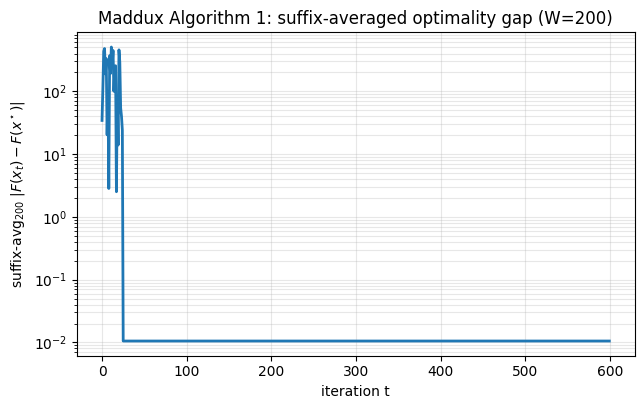

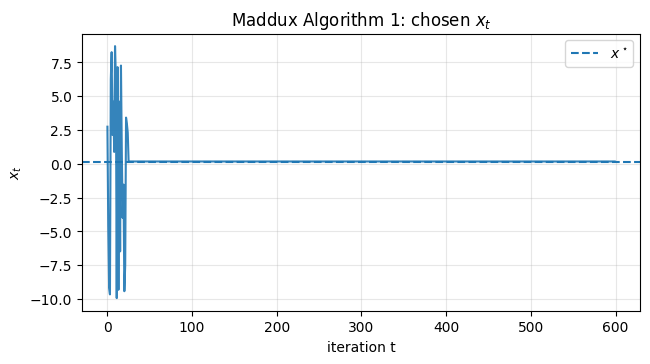

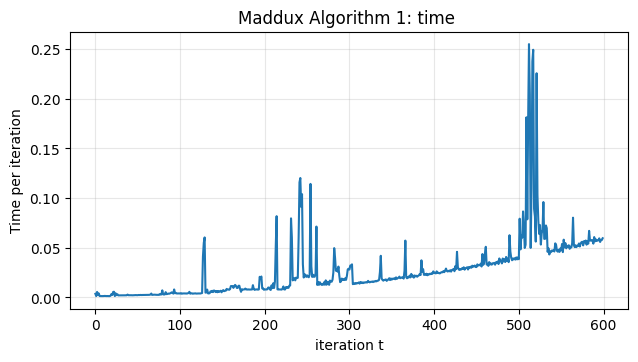

Summary:
  Best raw gap: 1.052e-02 at t=26, x=0.166667
  Final regret (W=200): 1.052e-02


In [ ]:

# Notebook-ready: Maddux Algorithm 1 (tuned) on Cournot bilevel + suffix-average plot (W=200)
# - Self-contained: defines the problem, runs the algorithm, computes gaps

import numpy as np
import matplotlib.pyplot as plt
import math
import time

# =========================
# 1) Cournot bilevel instance (same setup as we've been using)
# =========================
a=12; b=0.1; c=20; k=3
Rx=10; Ry=100
mu_x=10; gamma=1; Qdes=10

def proj_x(x: float) -> float:
    return float(np.clip(x, -Rx, Rx))

def proj_y(y: np.ndarray) -> np.ndarray:
    return np.clip(y, 0.0, Ry)

def Q(y: np.ndarray) -> float:
    return float(np.sum(y))

def y_star(x: float) -> np.ndarray:
    """True follower equilibrium (closed form symmetric equilibrium for this Cournot)."""
    denom = c + b * (k + 1.0)
    yi = np.clip((a + x) / denom, 0.0, Ry)
    return yi * np.ones(k)

def f(x: float, y: np.ndarray) -> float:
    """Leader objective at (x,y)."""
    return 0.5 * mu_x * x * x + 0.5 * gamma * (Q(y) - Qdes) ** 2

def F(x: float) -> float:
    """True bilevel objective F(x)=f(x,y*(x))."""
    return f(x, y_star(x))

# Closed-form minimizer of F(x) for this instance (quadratic in x), projected to [-Rx,Rx]
denom = c + b * (k + 1.0)
A = mu_x + gamma * (k / denom) ** 2
B = gamma * (k / denom) * (k * a / denom - Qdes)
x_star = proj_x(-B / A)
F_star = F(x_star)

print("Problem parameters:")
print(f"a={a}, b={b}, c={c}, k={k}, Rx={Rx}, Ry={Ry}, mu_x={mu_x}, gamma={gamma}, Qdes={Qdes}")
print(f"x* ≈ {x_star:.6f},  F(x*) ≈ {F_star:.6f}")

# =========================
# 2) Inner solver: ApproxNE via Gauss–Seidel best response (works for b>0)
# =========================
def approx_NE(x: float, K: int = 40, y0: np.ndarray | None = None) -> np.ndarray:
    """
    Approximate Nash equilibrium for followers given x by best-response iteration:
      y_i <- proj( (a + x - b*sum_{j≠i} y_j) / (c + 2b), [0,Ry] ).
    """
    if y0 is None:
        y = np.zeros(k, dtype=float)
    else:
        y = y0.astype(float).copy()

    denom_br = c + 2.0 * b
    for _ in range(K):
        S = float(np.sum(y))
        for i in range(k):
            S_minus = S - float(y[i])
            yi = (a + x - b * S_minus) / denom_br
            yi = float(np.clip(yi, 0.0, Ry))
            # update running sum efficiently
            S = S_minus + yi
            y[i] = yi
    return y

# =========================
# 3) Gaussian Process surrogate (RBF) + LCB acquisition (BO-style)
#    Tuned for speed:
#      - small candidate grid
#      - cap GP memory to a small window
#      - vectorized kernel computations
#      - larger jitter/noise for numerical stability
# =========================
def rbf_kernel_vec(X: np.ndarray, Y: np.ndarray, ell: float, var: float) -> np.ndarray:
    """Vectorized RBF kernel between 1D arrays X (n,), Y (m,)."""
    X = X[:, None]
    Y = Y[None, :]
    d2 = (X - Y) ** 2
    return var * np.exp(-0.5 * d2 / (ell ** 2))

def gp_posterior(X: np.ndarray, y: np.ndarray, Xtest: np.ndarray,
                 noise: float, ell: float, var: float):
    """
    GP posterior mean/std for 1D inputs.
    Returns (mu, std) at Xtest.
    """
    # Standardize observations for stability
    y_mean = float(y.mean())
    y_std = float(y.std())
    if y_std < 1e-12:
        y_std = 1.0
    ys = (y - y_mean) / y_std

    K = rbf_kernel_vec(X, X, ell, var) + (noise + 1e-10) * np.eye(len(X))
    Ks = rbf_kernel_vec(X, Xtest, ell, var)

    # Cholesky
    L = np.linalg.cholesky(K)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, ys))

    mu_s = Ks.T @ alpha
    v = np.linalg.solve(L, Ks)
    var_s = np.maximum(var - np.sum(v * v, axis=0), 1e-12)
    std_s = np.sqrt(var_s)

    mu = mu_s * y_std + y_mean
    std = std_s * y_std
    return mu, std

# =========================
# 4) Maddux Algorithm 1 loop + suffix-average plot
# =========================
T = 600                # Keep moderate so notebook runs fast
W = 200                 # suffix-average window size requested
Nwarm = 25              # warm-start random evaluations

grid = np.linspace(-Rx, Rx, 121)   # candidate set (smaller -> faster)

max_n = 15              # cap GP memory tightly for speed (sliding window)
noise = 2e-3            # GP observation noise / jitter (bigger -> more stable)
ell = 3.0               # kernel lengthscale
var = 1.0               # kernel variance

beta0 = 2.0
def beta_t(t: int) -> float:
    # Decaying exploration weight to encourage convergence
    return beta0 / math.sqrt(max(t, 1))

rng = np.random.default_rng(0)

X_hist = []     # x points used by GP
y_hist = []     # observed objectives for GP (f(x, y_approx))
xs = []         # algorithm-chosen x_t
gaps = []       # |F(x_t)-F(x*)|
y_prev = None   # warm start for inner NE solver
time_elapsed = np.zeros(T)

for t in range(1, T + 1):
    # Choose x_t
    start_time = time.time()
    if t <= Nwarm:
        x_t = float(rng.uniform(-Rx, Rx))
    else:
        X_np = np.asarray(X_hist, dtype=float)
        y_np = np.asarray(y_hist, dtype=float)
        mu, std = gp_posterior(X_np, y_np, grid, noise=noise, ell=ell, var=var)

        # LCB for minimization
        acq = mu - beta_t(t) * std
        x_t = float(grid[int(np.argmin(acq))])

    # Inner solve accuracy grows slowly with t (helps stability/convergence)
    #K_inner = int(30 + 10 * math.log(t + 1))
    y_t = approx_NE(x_t, y0=y_prev)
    y_prev = y_t

    # Observe bandit feedback
    J_obs = f(x_t, y_t)
    X_hist.append(x_t)
    y_hist.append(J_obs)
    end_time = time.time()
    time_elapsed[t-1] = end_time - start_time

    # Record metrics using the true bilevel objective (since we know y*(x))
    xs.append(x_t)
    gaps.append(abs(F(x_t) - F_star))

xs = np.asarray(xs, dtype=float)
gaps = np.asarray(gaps, dtype=float)



# =========================
# 5) Plots
# =========================
plt.figure(figsize=(7.2, 4.2))
plt.semilogy(gaps, linewidth=2)
plt.xlabel("iteration t")
plt.ylabel(r"suffix-avg$_{200}$ $|F(x_t)-F(x^\star)|$")
plt.title("Maddux Algorithm 1: suffix-averaged optimality gap (W=200)")
plt.grid(True, which="both", alpha=0.3)
plt.show()

plt.figure(figsize=(7.2, 3.6))
plt.plot(xs, alpha=0.9)
plt.axhline(x_star, linestyle="--", label=r"$x^\star$")
plt.xlabel("iteration t")
plt.ylabel(r"$x_t$")
plt.title("Maddux Algorithm 1: chosen $x_t$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(7.2, 3.6))
plt.plot(time_elapsed[:T])
plt.xlabel("iteration t")
plt.ylabel("Time per iteration")
plt.title("Maddux Algorithm 1: time ")
plt.grid(True, alpha=0.3)

plt.show()

# =========================
# 6) Summary
# =========================
best_idx = int(np.argmin(gaps))
print("Summary:")
print(f"  Best raw gap: {gaps[best_idx]:.3e} at t={best_idx+1}, x={xs[best_idx]:.6f}")
print(f"  Final regret (W=200): {gaps[-1]:.3e}")


Problem parameters:
a=12, b=0.01, c=2000, k=2000, Rx=100, Ry=1000, mu_x=10, gamma=1, Qdes=10
x* ≈ -0.169622,  F(x*) ≈ 1.611364


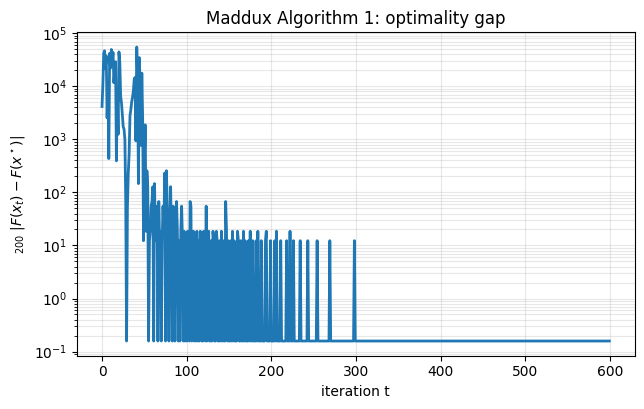

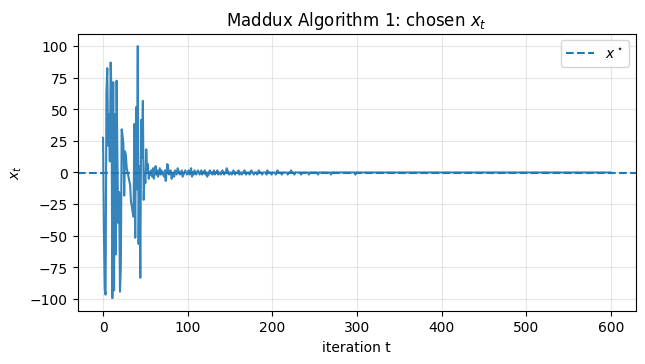

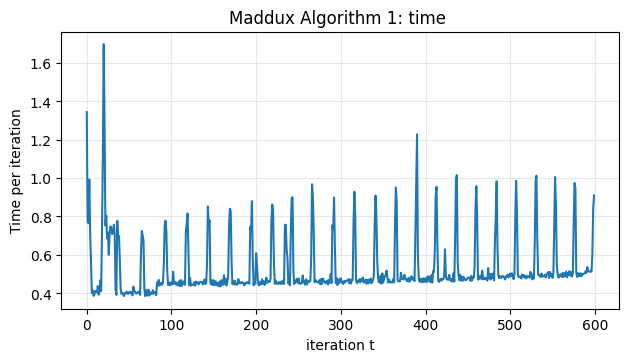

Summary:
Time per iteration: 0.5273085184892019
  Best raw gap: 1.580e-01 at t=30, x=0.000000
  Final regret (W=200): 1.580e-01
Time to converges: 156.12506866455078


In [ ]:

# Notebook-ready: Maddux Algorithm 1 (tuned) on Cournot bilevel
# - Self-contained: defines the problem, runs the algorithm, computes gaps

import numpy as np
import matplotlib.pyplot as plt
import math
import time

# =========================
# 1) Cournot bilevel instance (same setup as we've been using)
# =========================
a=12; b=0.01; c=2000; k=2000
Rx=100; Ry=1000
mu_x=10; gamma=1; Qdes=10
den=c+b*(k+1)

def proj_x(x: float) -> float:
    return float(np.clip(x, -Rx, Rx))

def proj_y(y: np.ndarray) -> np.ndarray:
    return np.clip(y, 0.0, Ry)

def Q(y: np.ndarray) -> float:
    return float(np.sum(y))

def y_star(x: float) -> np.ndarray:
    """True follower equilibrium (closed form symmetric equilibrium for this Cournot)."""
    denom = c + b * (k + 1.0)
    yi = np.clip((a + x) / denom, 0.0, Ry)
    return yi * np.ones(k)

def f(x: float, y: np.ndarray) -> float:
    """Leader objective at (x,y)."""
    return 0.5 * mu_x * x * x + 0.5 * gamma * (Q(y) - Qdes) ** 2

def F(x: float) -> float:
    """True bilevel objective F(x)=f(x,y*(x))."""
    return f(x, y_star(x))

# Closed-form minimizer of F(x) for this instance (quadratic in x), projected to [-Rx,Rx]
denom = c + b * (k + 1.0)
A = mu_x + gamma * (k / denom) ** 2
B = gamma * (k / denom) * (k * a / denom - Qdes)
x_star = proj_x(-B / A)
F_star = F(x_star)

print("Problem parameters:")
print(f"a={a}, b={b}, c={c}, k={k}, Rx={Rx}, Ry={Ry}, mu_x={mu_x}, gamma={gamma}, Qdes={Qdes}")
print(f"x* ≈ {x_star:.6f},  F(x*) ≈ {F_star:.6f}")

# =========================
# 2) Inner solver: ApproxNE via Gauss–Seidel best response (works for b>0)
# =========================
def approx_NE(x: float, K: int = 40, y0: np.ndarray | None = None) -> np.ndarray:
    """
    Approximate Nash equilibrium for followers given x by best-response iteration:
      y_i <- proj( (a + x - b*sum_{j≠i} y_j) / (c + 2b), [0,Ry] ).
    """
    if y0 is None:
        y = np.zeros(k, dtype=float)
    else:
        y = y0.astype(float).copy()

    denom_br = c + 2.0 * b
    for _ in range(K):
        S = float(np.sum(y))
        for i in range(k):
            S_minus = S - float(y[i])
            yi = (a + x - b * S_minus) / denom_br
            yi = float(np.clip(yi, 0.0, Ry))
            # update running sum efficiently
            S = S_minus + yi
            y[i] = yi
    return y

# =========================
# 3) Gaussian Process surrogate (RBF) + LCB acquisition (BO-style)
#    Tuned for speed:
#      - small candidate grid
#      - cap GP memory to a small window
#      - vectorized kernel computations
#      - larger jitter/noise for numerical stability
# =========================
def rbf_kernel_vec(X: np.ndarray, Y: np.ndarray, ell: float, var: float) -> np.ndarray:
    """Vectorized RBF kernel between 1D arrays X (n,), Y (m,)."""
    X = X[:, None]
    Y = Y[None, :]
    d2 = (X - Y) ** 2
    return var * np.exp(-0.5 * d2 / (ell ** 2))

def gp_posterior(X: np.ndarray, y: np.ndarray, Xtest: np.ndarray,
                 noise: float, ell: float, var: float):
    """
    GP posterior mean/std for 1D inputs.
    Returns (mu, std) at Xtest.
    """
    # Standardize observations for stability
    y_mean = float(y.mean())
    y_std = float(y.std())
    if y_std < 1e-12:
        y_std = 1.0
    ys = (y - y_mean) / y_std

    K = rbf_kernel_vec(X, X, ell, var) + (noise + 1e-10) * np.eye(len(X))
    Ks = rbf_kernel_vec(X, Xtest, ell, var)

    # Cholesky
    L = np.linalg.cholesky(K)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, ys))

    mu_s = Ks.T @ alpha
    v = np.linalg.solve(L, Ks)
    var_s = np.maximum(var - np.sum(v * v, axis=0), 1e-12)
    std_s = np.sqrt(var_s)

    mu = mu_s * y_std + y_mean
    std = std_s * y_std
    return mu, std

# =========================
# 4) Maddux Algorithm 1 loop + suffix-average plot
# =========================
T = 600                # Keep moderate so notebook runs fast
Nwarm = 25              # warm-start random evaluations

grid = np.linspace(-Rx, Rx, 121)   # candidate set (smaller -> faster)

max_n = 15              # cap GP memory tightly for speed (sliding window)
noise = 2e-3            # GP observation noise / jitter (bigger -> more stable)
ell = 3.0               # kernel lengthscale
var = 1.0               # kernel variance

beta0 = 8.0
def beta_t(t: int) -> float:
    # Decaying exploration weight to encourage convergence
    return beta0 / math.sqrt(max(t, 1))

rng = np.random.default_rng(0)

X_hist = []     # x points used by GP
y_hist = []     # observed objectives for GP (f(x, y_approx))
xs = []         # algorithm-chosen x_t
gaps = []       # |F(x_t)-F(x*)|
y_prev = None   # warm start for inner NE solver
time_elapsed = np.zeros(T)

for t in range(1, T + 1):
    # Choose x_t
    start_time = time.time()
    if t <= Nwarm:
        x_t = float(rng.uniform(-Rx, Rx))
    else:
        X_np = np.asarray(X_hist, dtype=float)
        y_np = np.asarray(y_hist, dtype=float)
        mu, std = gp_posterior(X_np, y_np, grid, noise=noise, ell=ell, var=var)

        # LCB for minimization
        acq = mu - beta_t(t) * std
        x_t = proj_x(float(grid[int(np.argmin(acq))]))

    # Inner solve accuracy grows slowly with t (helps stability/convergence)
    #K_inner = int(30 + 10 * math.log(t + 1))
    y_t = approx_NE(x_t, y0=y_prev)
    y_prev = y_t

    # Observe bandit feedback
    J_obs = f(x_t, y_t)
    X_hist.append(x_t)
    y_hist.append(J_obs)
    end_time = time.time()
    time_elapsed[t-1] = end_time - start_time

    # Record metrics using the true bilevel objective (since we know y*(x))
    xs.append(x_t)
    gaps.append(abs(F(x_t) - F_star))

xs = np.asarray(xs, dtype=float)
gaps_0th = np.asarray(gaps, dtype=float)



# =========================
# 5) Plots
# =========================
plt.figure(figsize=(7.2, 4.2))
plt.semilogy(gaps_0th, linewidth=2)
plt.xlabel("iteration t")
plt.ylabel(r"$_{200}$ $|F(x_t)-F(x^\star)|$")
plt.title("Maddux Algorithm 1: optimality gap")
plt.grid(True, which="both", alpha=0.3)
plt.show()

plt.figure(figsize=(7.2, 3.6))
plt.plot(xs, alpha=0.9)
plt.axhline(x_star, linestyle="--", label=r"$x^\star$")
plt.xlabel("iteration t")
plt.ylabel(r"$x_t$")
plt.title("Maddux Algorithm 1: chosen $x_t$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(7.2, 3.6))
plt.plot(time_elapsed[:T])
plt.xlabel("iteration t")
plt.ylabel("Time per iteration")
plt.title("Maddux Algorithm 1: time ")
plt.grid(True, alpha=0.3)

plt.show()

# =========================
# 6) Summary
# =========================
best_idx = int(np.argmin(gaps_0th))
print("Summary:")
print (f"Time per iteration: {time_elapsed.mean()}")
print(f"  Best raw gap: {gaps_0th[best_idx]:.3e} at t={best_idx+1}, x={xs[best_idx]:.6f}")
print(f"  Final regret (W=200): {gaps_0th[-1]:.3e}")
print(f"Time to converges: {sum(time_elapsed[0:300])}")

## Wang el al: second-order method

pi* = -0.16962172132628175 F* = 1.6113639196804959
pi_T = -0.1696217184326426 gap_T = 1.1102230246251565e-15 grad_T = 1.1102230246251565e-15
Average time per iteration = 0.21783755917638278
Time to converges=  65.61378979700476


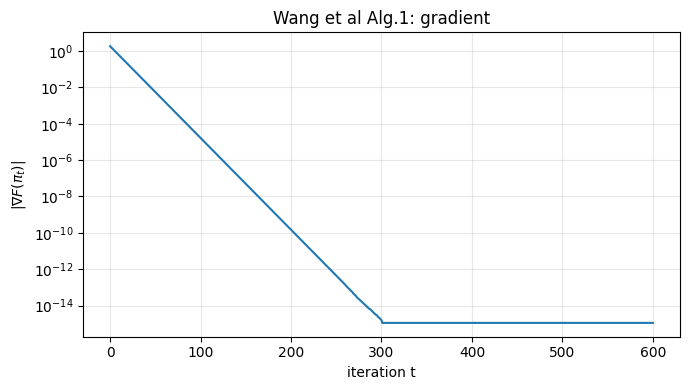

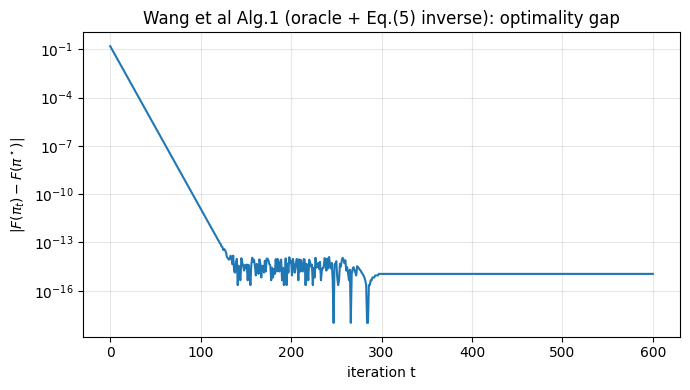

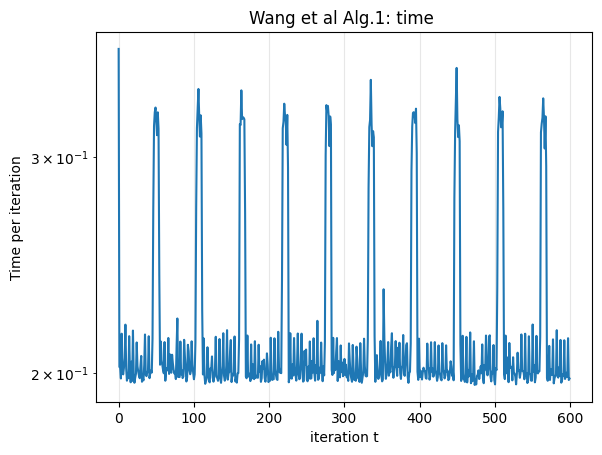

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# =========================
# Cournot instance
# =========================


a=12; b=0.01; c=2000; k=2000
Rx=100; Ry=1000
mu_x=10; gamma=1; Q_des=10

def proj_pi(pi):  # leader projection
    return float(np.clip(pi, -Rx, Rx))

def proj_y(y):
    return np.clip(y, 0.0, Ry)

def Q(y):
    return float(np.sum(y))

# =========================
# Oracle: black-box access to follower equilibrium y*(pi)
# (internally uses the known closed-form, but the algorithm only calls this function)
# =========================
def oracle_y_star(pi):
    denom = c + b*(k+1.0)
    yi = (a + pi)/denom
    yi = float(np.clip(yi, 0.0, Ry))
    return yi*np.ones(k, dtype=float)

# =========================
# Cournot leader objective f(pi,y) and bilevel objective F(pi)=f(pi,y*(pi))
# =========================
def f_cournot(pi, y):
    return 0.5*mu_x*pi*pi + 0.5*gamma*(Q(y)-Q_des)**2

def F(pi):
    y = oracle_y_star(pi)
    return f_cournot(pi, y)

# =========================
# Wang paper's f and g
# You asked: MINIMIZE F(pi) <=> MAXIMIZE -F(pi)
# Eq.(10) uses -E[f_paper], so set f_paper := - f_cournot,
# then -E[f_paper] = E[f_cournot] = F.
# =========================
def f_paper(pi, ystar):
    return -f_cournot(pi, ystar)

# In your screenshot Cournot has NO leader constraints, so g ≡ 0.
# (Then lambda/slack updates do nothing, but the implementation matches Alg.1 structure.)
def g_paper(pi, ystar):
    return 0.0

# =========================
# Eq.(5): compute dy*/dpi as (dF/dy)^{-1} * (-dF/dpi) for follower stationarity system.
#
# Cournot stationarity residual (interior) is:
#   F_i(y,pi) = (c+b) y_i + b(1^T y) - (a+pi) = 0
# Jacobian wrt y: J = (c+b)I + b 11^T
# dF/dpi = -1 vector, so RHS = 1 vector.
#
# Need v = J^{-1} 1.
# =========================
# --- global cache for J (optional but recommended) ---
_J_cache = None

def dy_dpi_via_eq5_solve(pi: float) -> np.ndarray:
    """
    Compute dy*/dpi via Eq.(5) by explicitly solving the linear system
        J v = rhs
    where
        J = (c+b) I + b 11^T
        rhs = 1

    This is mathematically equivalent to using J^{-1},
    but numerically stable and fast.
    """
    global _J_cache

    denom = c + b*(k+1.0)
    yi_unproj = (a + pi) / denom

    # If projection is active, equilibrium is locally flat
    if yi_unproj <= 0.0 or yi_unproj >= Ry:
        return np.zeros(k, dtype=float)

    # Build J once (it does not depend on pi in the interior)
    if _J_cache is None:
        I = np.eye(k, dtype=float)
        ones = np.ones((k, 1), dtype=float)
        _J_cache = (c + b) * I + b * (ones @ ones.T)

    rhs = np.ones(k, dtype=float)
    return np.linalg.solve(_J_cache, rhs)


# =========================
# Algorithm 1: Augmented Lagrangian method (Wang et al.)
# For your unconstrained Cournot screenshot, g≡0 so lambda/s are inert;
# the pi-update becomes gradient descent on F(pi), computed via oracle + Eq.(5).
# =========================
def run_wang_alg1(T=500, pi0=0.0, lr=0.01, mu_pen=1.0, K=100, lam0=0.0, s0=0.0):
    pi = proj_pi(pi0)
    lam = float(lam0)
    s = max(float(s0), 0.0)

    pis = np.zeros(T+1)
    Fs  = np.zeros(T+1)
    gradabs = np.zeros(T+1)

    time_elapsed = np.zeros(T+1)

    for t in range(T+1):

        start_time = time.perf_counter()
        pis[t] = pi

        # monitor true gradient of F using oracle + Eq.(5)
        ystar = oracle_y_star(pi)
        Fs[t] = f_cournot(pi, ystar)
        dy = dy_dpi_via_eq5_solve(pi)

        dQdpi = float(np.sum(dy))

        # dF/dpi = mu_x*pi + gamma*(Q(y*)-Q_des)* dQ/dpi
        gradF = mu_x*pi + gamma*(Q(ystar)-Q_des)*dQdpi
        gradabs[t] = abs(gradF)

        if t == T:
            break

        # ---- Alg.1 line 4: sampled gradient of L by sampling x*~O(pi)
        # Here x* is y* from oracle, and f_paper is -f_cournot so -E[f_paper]=F
        # With g≡0, L = F(pi) + lam*(0+s) + (mu/2)(0+s)^2 = F(pi) + lam*s + (mu/2)s^2
        # pi-gradient is just gradF (since g does not depend on pi in this unconstrained example).
        dL_dpi = gradF

        # s-gradient: dL/ds = lam + mu*s  (since g≡0)
        dL_ds = lam + mu_pen*s

        # ---- Alg.1 line 5: update pi and s
        pi = proj_pi(pi - lr*dL_dpi)
        s = max(s - lr*dL_ds, 0.0)


        # ---- Alg.1 line 6-7: lambda update every K steps (MATCH pseudo-code)
        if (t+1) % K == 0:
            gval = g_paper(pi, oracle_y_star(pi))  # 0.0 here
            lam = lam - mu_pen*(gval + s)
        end_time = time.perf_counter()
        time_elapsed[t] = end_time - start_time

    return pis, Fs, gradabs, time_elapsed

# =========================
# Run + plots
# =========================
T=600
pis, Fs, gradabs, time_elapsed = run_wang_alg1(T=T, pi0=0.0, lr=0.01, mu_pen=1.0, K=100, lam0=0.0, s0=0.0)

# Compute reference optimum by 1D golden search on F (for plotting gap)
def golden_min(f, a0, b0, tol=1e-12, maxit=4000):
    import math
    gr=(math.sqrt(5)-1)/2
    a_=a0; b_=b0
    c_=b_-gr*(b_-a_); d_=a_+gr*(b_-a_)
    fc=f(c_); fd=f(d_)
    for _ in range(maxit):
        if abs(b_-a_)<tol: break
        if fc<fd:
            b_=d_; d_=c_; fd=fc
            c_=b_-gr*(b_-a_); fc=f(c_)
        else:
            a_=c_; c_=d_; fc=fd
            d_=a_+gr*(b_-a_); fd=f(d_)
    x_=(a_+b_)/2
    return x_, f(x_)

pi_star, F_star = golden_min(F, -Rx, Rx)
gaps_2nd = np.abs(Fs - F_star)

print("pi* =", pi_star, "F* =", F_star)
print("pi_T =", pis[-1], "gap_T =", gaps_2nd[-1], "grad_T =", gradabs[-1])
print("Average time per iteration =", np.mean(time_elapsed))
print("Time to converges= ", sum(time_elapsed[0:300]))

plt.figure(figsize=(7,4))
plt.semilogy(np.maximum(gradabs, 1e-18))
plt.xlabel("iteration t"); plt.ylabel(r"$|\nabla F(\pi_t)|$")
plt.title("Wang et al Alg.1: gradient")
plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.semilogy(np.maximum(gaps_2nd, 1e-18))
plt.xlabel("iteration t"); plt.ylabel(r"$|F(\pi_t)-F(\pi^\star)|$")
plt.title("Wang et al Alg.1 (oracle + Eq.(5) inverse): optimality gap")
plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()


plt.figure()
plt.semilogy(time_elapsed[:T])
plt.xlabel("iteration t")
plt.ylabel("Time per iteration")
plt.title("Wang et al Alg.1: time ")
plt.grid(True, alpha=0.3)

plt.show()



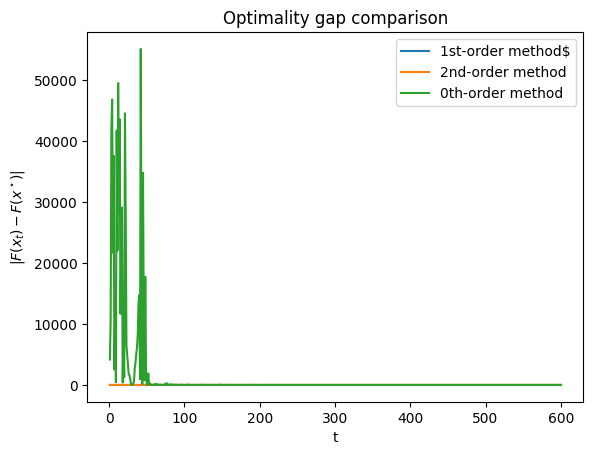

In [ ]:
t=np.arange(1,600+1)

plt.figure()
plt.plot(t, gaps_1st, label=r'1st-order method')
plt.plot(t, gaps_2nd[:600], label=r'2nd-order method')
plt.plot(t, gaps_0th, label=r'0th-order method')
plt.xscale('linear')
plt.yscale('linear')
plt.xlabel('t')
plt.ylabel(r'$|F(x_t)-F(x^\star)|$')
plt.title('Optimality gap comparison')
plt.legend()

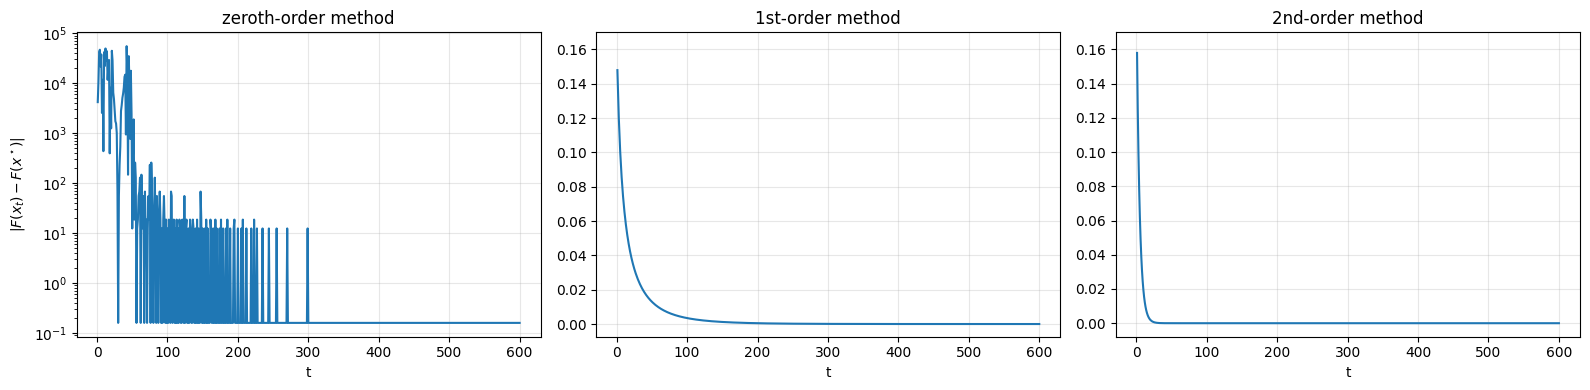

In [ ]:
import matplotlib.ticker as mtick
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)
t=np.arange(1,T+1)

axes[0].plot(t, gaps_0th)
axes[0].set_title("zeroth-order method")
axes[0].set_xlabel("t")
axes[0].set_ylabel(r'$|F(x_t)-F(x^\star)|$')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)



axes[1].plot(t, gaps_1st, label = r'$|F(x_t)-F(x^\star)|$')
#t_arr = np.asarray(t, dtype=float)
#axes[1].plot(t_arr, 1.0 / (t_arr**2), '--', label=r'Reference: $1/t^2$')
axes[1].set_title("1st-order method")
axes[1].set_xlabel("t")
#axes[1].yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2e'))
axes[1].set_ylim([None,0.17])
#axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

axes[2].plot(t, gaps_2nd[:T])
axes[2].set_title("2nd-order method")
axes[2].set_xlabel("t")
axes[2].set_ylim([None,0.17])
#axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In this example we consider a Stackelberg game where the followers play a 2-player zero-sum game. Concretely, the followers play a game
$$\min_{y_1 \in \mathbb R^n} \max_{y_2 \in \mathbb R^m} g(A, y_1, y_2) $$
where $$g(A, y_1, y_2) = \frac12 y_1^\top H y_1 - h^\top y_1 + y_2^\top A y_1 - \frac12 y_2^\top Gy_2 + r^\top y_2.$$ THe leader's objective is to choose a matrix $A\in \mathbb R^{m\times n}$ to minimize
$$f (A,y_1, y_2) = \frac{\mu_A}{2} \Vert A- A_0\Vert^2_F + \frac{\gamma_1}{2} \Vert y_1 - u \Vert^2 + \frac{\gamma_2}{2}\Vert y_2 -v\Vert^2.$$

In this example, we chose $n = m = 5$, $\gamma_1 = \gamma_2 = \mu_A = 1$, and $A_0$ is a $m\times n$ matrix with all zeros.

final_eta        = 2.710732565667287e-05
final_lambda     = 11067.237839776653
||A*||_F         = 0.7305572332731672
||A_T||_F        = 0.4188370976162223
F(A*)            = 1.7250282210720211
final_F_gap      = 0.11773558005336127
final_gradF_norm = 0.5076745489197273
final_z_err      = 8.253998968961136e-11
final_y_err      = 0.0001458630393592349
A*               = [[ 0.19920333 -0.2561835   0.22752574 -0.15618022  0.20478748]
 [-0.16280749  0.22210036 -0.19056831  0.14008354 -0.17057012]
 [-0.01607622  0.0552261  -0.0308929   0.04638099 -0.02522195]
 [ 0.18211762 -0.18227581  0.18917386 -0.09201459  0.17414984]
 [ 0.01412641  0.02106058  0.00190631  0.02727235  0.00464682]]


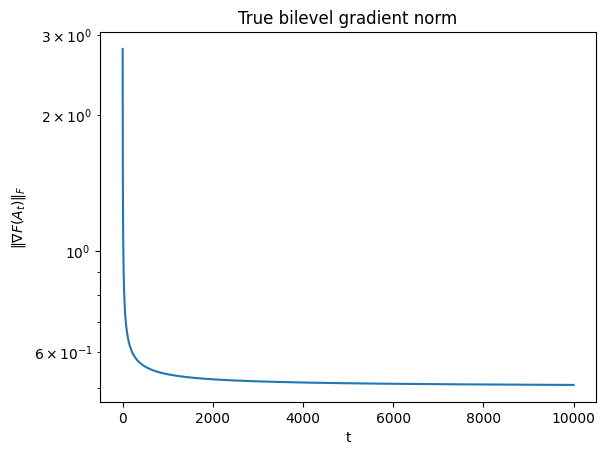

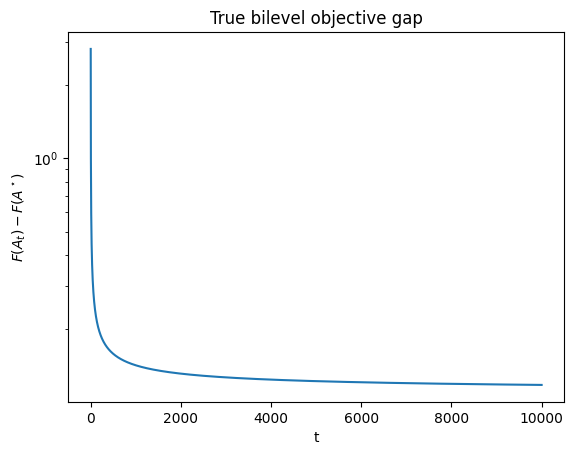

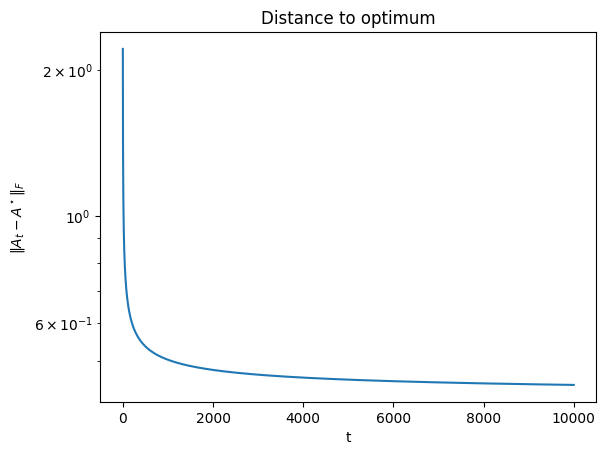

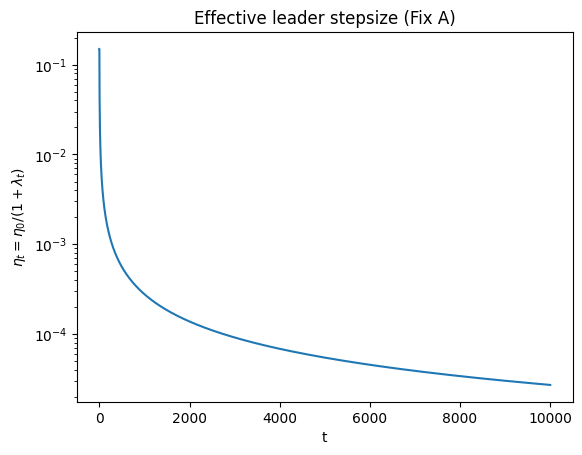

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

# ----------------------------
# Utilities: projections
# ----------------------------
def proj_ball(y: np.ndarray, R: float) -> np.ndarray:
    nrm = float(np.linalg.norm(y))
    if nrm <= R or nrm == 0.0:
        return y
    return (R / nrm) * y

def proj_fro_ball(A: np.ndarray, R: float) -> np.ndarray:
    nrm = float(np.linalg.norm(A, ord="fro"))
    if nrm <= R or nrm == 0.0:
        return A
    return (R / nrm) * A

# ----------------------------
# Problem definition
# ----------------------------
@dataclass
class Params:
    n: int = 5             # dim y1
    m: int = 5             # dim y2
    R1: float = 10.0       # ball radius for y1
    R2: float = 10.0       # ball radius for y2
    RA: float = 2.0        # Frobenius ball radius for A

    mu_A: float = 1.0      # leader regularization weight
    gamma1: float = 1.0    # leader coupling weight on y1
    gamma2: float = 1.0    # leader coupling weight on y2

    seed: int = 1

    # If None, created randomly but SPD
    H: np.ndarray | None = None
    G: np.ndarray | None = None
    h: np.ndarray | None = None
    r: np.ndarray | None = None

    A0: np.ndarray | None = None  # leader reference matrix
    u: np.ndarray | None = None   # leader reference y1
    v: np.ndarray | None = None   # leader reference y2

    def __post_init__(self):
        rng = np.random.default_rng(self.seed)

        if self.H is None:
            eig = np.linspace(1.0, 3.0, self.n)
            Q, _ = np.linalg.qr(rng.standard_normal((self.n, self.n)))
            self.H = Q @ np.diag(eig) @ Q.T

        if self.G is None:
            eig = np.linspace(1.0, 2.5, self.m)
            Q, _ = np.linalg.qr(rng.standard_normal((self.m, self.m)))
            self.G = Q @ np.diag(eig) @ Q.T

        if self.h is None:
            self.h = rng.standard_normal(self.n)
        if self.r is None:
            self.r = rng.standard_normal(self.m)

        if self.A0 is None:
            self.A0 = np.zeros((self.m, self.n))
        if self.u is None:
            self.u = np.zeros(self.n)
        if self.v is None:
            self.v = np.zeros(self.m)

class ZeroSumBilevel:
    """
    Followers' saddle function:
      g(A,y1,y2)=0.5 y1^T H y1 - h^T y1 + y2^T A y1 - 0.5 y2^T G y2 + r^T y2
    Player objectives:
      g1 = g,   g2 = -g
    Strongly monotone VI operator:
      F=(∇_{y1} g, ∇_{y2}(-g)) = (H y1 - h + A^T y2, G y2 - A y1 - r)
    """
    def __init__(self, p: Params):
        self.p = p
        self.H_op = float(np.linalg.norm(p.H, 2))
        self.G_op = float(np.linalg.norm(p.G, 2))

    # Lower-level saddle g and gradients
    def g(self, A: np.ndarray, y1: np.ndarray, y2: np.ndarray) -> float:
        p = self.p
        return float(
            0.5 * y1.T @ p.H @ y1
            - p.h.T @ y1
            + y2.T @ (A @ y1)
            - 0.5 * y2.T @ p.G @ y2
            + p.r.T @ y2
        )

    def grad_y1_g(self, A: np.ndarray, y1: np.ndarray, y2: np.ndarray) -> np.ndarray:
        p = self.p
        return p.H @ y1 - p.h + A.T @ y2

    def grad_y2_g(self, A: np.ndarray, y1: np.ndarray, y2: np.ndarray) -> np.ndarray:
        p = self.p
        return A @ y1 - p.G @ y2 + p.r

    # VI operator for strongly monotone game
    def F_vi(self, A: np.ndarray, y1: np.ndarray, y2: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        p = self.p
        F1 = p.H @ y1 - p.h + A.T @ y2
        F2 = p.G @ y2 - A @ y1 - p.r
        return F1, F2

    def lipschitz_vi(self, A: np.ndarray) -> float:
        Aop = float(np.linalg.norm(A, 2))
        return self.H_op + self.G_op + 2.0 * Aop

    def solve_vi_projected(self, A: np.ndarray, y1: np.ndarray, y2: np.ndarray, n_steps: int) -> tuple[np.ndarray, np.ndarray]:
        """
        Simple projected fixed-point iteration for the VI:
          (y1,y2) <- Proj( (y1,y2) - step * F_vi(A,y1,y2) )
        step = 1/L ensures stability for monotone Lipschitz operators.
        """
        p = self.p
        step = 1.0 / self.lipschitz_vi(A)
        for _ in range(n_steps):
            F1, F2 = self.F_vi(A, y1, y2)
            y1 = proj_ball(y1 - step * F1, p.R1)
            y2 = proj_ball(y2 - step * F2, p.R2)
        return y1, y2

    # Exact equilibrium (unconstrained) for diagnostics
    def y_star(self, A: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        p = self.p
        K = np.block([[p.H, A.T], [-A, p.G]])
        rhs = np.concatenate([p.h, p.r])
        sol = np.linalg.solve(K, rhs)
        return sol[:p.n], sol[p.n:]

    # Leader loss f(A,y)
    def f(self, A: np.ndarray, y1: np.ndarray, y2: np.ndarray) -> float:
        p = self.p
        return float(
            0.5 * p.mu_A * np.linalg.norm(A - p.A0, ord="fro") ** 2
            + 0.5 * p.gamma1 * np.linalg.norm(y1 - p.u) ** 2
            + 0.5 * p.gamma2 * np.linalg.norm(y2 - p.v) ** 2
        )

    def grad_A_f(self, A: np.ndarray) -> np.ndarray:
        p = self.p
        return p.mu_A * (A - p.A0)

    def grad_y1_f(self, y1: np.ndarray) -> np.ndarray:
        p = self.p
        return p.gamma1 * (y1 - p.u)

    def grad_y2_f(self, y2: np.ndarray) -> np.ndarray:
        p = self.p
        return p.gamma2 * (y2 - p.v)

    # True bilevel objective F(A)=f(A,y*(A)) and exact gradient (diagnostic)
    def F(self, A: np.ndarray) -> float:
        y1s, y2s = self.y_star(A)
        return self.f(A, y1s, y2s)

    def grad_F(self, A: np.ndarray) -> np.ndarray:
        """
        Exact hypergradient for diagnostics via implicit differentiation:
          y*(A) solves K(A) y = rhs
          K(A) = [[H, A^T], [-A, G]]
        """
        p = self.p
        y1, y2 = self.y_star(A)

        # direct term
        grad = p.mu_A * (A - p.A0)

        # implicit term
        p_y = np.concatenate([p.gamma1 * (y1 - p.u), p.gamma2 * (y2 - p.v)])
        K = np.block([[p.H, A.T], [-A, p.G]])
        v = np.linalg.solve(K.T, p_y)
        v1, v2 = v[:p.n], v[p.n:]

        # d/dA of y2^T A y1 contributes outer(v2, y1) - outer(y2, v1)
        grad += np.outer(v2, y1) - np.outer(y2, v1)
        return grad

    # Gradients of g_i w.r.t. A (player objectives)
    def grad_A_g1(self, y1: np.ndarray, y2: np.ndarray) -> np.ndarray:
        # g1 = g, and A appears only in y2^T A y1
        return np.outer(y2, y1)

    def grad_A_g2(self, y1: np.ndarray, y2: np.ndarray) -> np.ndarray:
        # g2 = -g, so gradient is -outer(y2,y1)
        return -np.outer(y2, y1)

# ----------------------------
# Helper: approximate A* for diagnostics
# ----------------------------
def proj_gd_to_optimum(problem: ZeroSumBilevel, A_init: np.ndarray, step: float, iters: int) -> np.ndarray:
    """
    A* approx by projected GD on the *true* bilevel objective F (diagnostic only).
    """
    p = problem.p
    A = A_init.copy()
    for _ in range(iters):
        A = proj_fro_ball(A - step * problem.grad_F(A), p.RA)
    return A

# ----------------------------
# Algorithm 1 with UPDATED L-tilde + Fix A + Fix B
# ----------------------------
def run_algorithm1_fixA_fixB(
    problem: ZeroSumBilevel,
    T: int = 300,
    rho: float = 1.011,
    lambda0: float = 1.0,
    eta0: float = 0.3,                 # Fix A: eta_t = eta0/(1+lambda_t)
    A_init: np.ndarray | None = None,

    # Fix B: polynomial inner budgets with caps
    Mz0: float = 2.0,
    My0: float = 1.0,
    Mz_pow: float = 0.7,
    My_pow: float = 0.5,
    cap_Mz: int = 50,
    cap_My: int = 20,

    # y stepsize scaling (uses 1/L)
    y_stepsize_scale: float = 1.0,

    # diagnostics: compute A* via projected GD on true F
    Astar_step: float = 0.05,
    Astar_iters: int = 400,
    seed_init: int = 123,
):
    p = problem.p
    rng = np.random.default_rng(seed_init)

    if A_init is None:
        A_init = proj_fro_ball(rng.standard_normal((p.m, p.n)), p.RA)

    A = proj_fro_ball(A_init.copy(), p.RA)
    lam = float(lambda0)

    # y_t and z_t initializations
    y1 = np.zeros(p.n); y2 = np.zeros(p.m)
    z1 = np.zeros(p.n); z2 = np.zeros(p.m)

    # diagnostics target
    A_star = proj_gd_to_optimum(problem, A_init=A, step=Astar_step, iters=Astar_iters)
    F_star = problem.F(A_star)

    # storage
    gradF_norm = np.zeros(T + 1)
    F_gap = np.zeros(T + 1)
    A_dist = np.zeros(T + 1)
    z_err = np.zeros(T + 1)
    y_err = np.zeros(T + 1)
    lambdas = np.zeros(T + 1)
    etas = np.zeros(T + 1)
    Mz_hist = np.zeros(T + 1, dtype=int)
    My_hist = np.zeros(T + 1, dtype=int)

    # gradient wrt y of updated tilde-L (baseline g_i(A,z_{t+1}) has no y)
    def grad_y_tilde(A, y1, y2, z1, z2, lam):
        gy1 = problem.grad_y1_f(y1) + lam * problem.grad_y1_g(A, y1, z2)
        gy2 = problem.grad_y2_f(y2) - lam * problem.grad_y2_g(A, z1, y2)
        return gy1, gy2

    # t=0 diagnostics
    gradF_norm[0] = float(np.linalg.norm(problem.grad_F(A), ord="fro"))
    F_gap[0] = problem.F(A) - F_star
    A_dist[0] = float(np.linalg.norm(A - A_star, ord="fro"))
    z1s, z2s = problem.y_star(A)
    z_err[0] = float(np.linalg.norm(np.concatenate([z1 - z1s, z2 - z2s])))
    y_err[0] = float(np.linalg.norm(np.concatenate([y1 - z1s, y2 - z2s])))
    lambdas[0] = lam
    etas[0] = eta0 / (1.0 + lam)

    for t in range(1, T + 1):
        # Fix B: inner budgets
        Mz = min(cap_Mz, int(np.ceil(Mz0 * (t ** Mz_pow))))
        My = min(cap_My, int(np.ceil(My0 * (t ** My_pow))))
        Mz_hist[t] = Mz
        My_hist[t] = My

        # Step 1: z_{t+1} approx equilibrium at A_t
        z1, z2 = problem.solve_vi_projected(A, z1, z2, n_steps=Mz)

        # Step 2: y update by projected GD on tilde-L (My steps)
        Aop = float(np.linalg.norm(A, 2))
        Ly1 = p.gamma1 + lam * (float(np.linalg.norm(p.H, 2)) + Aop)
        Ly2 = p.gamma2 + lam * (float(np.linalg.norm(p.G, 2)) + Aop)
        step_y1 = y_stepsize_scale / Ly1
        step_y2 = y_stepsize_scale / Ly2

        for _ in range(My):
            gy1, gy2 = grad_y_tilde(A, y1, y2, z1, z2, lam)
            y1 = proj_ball(y1 - step_y1 * gy1, p.R1)
            y2 = proj_ball(y2 - step_y2 * gy2, p.R2)

        # equilibrium errors at current A (diagnostic)
        y1s, y2s = problem.y_star(A)
        z_err[t] = float(np.linalg.norm(np.concatenate([z1 - y1s, z2 - y2s])))
        y_err[t] = float(np.linalg.norm(np.concatenate([y1 - y1s, y2 - y2s])))

        # Fix A: leader stepsize
        eta_t = eta0 / (1.0 + lam)
        etas[t] = eta_t

        # UPDATED definition:
        # \tilde L = f(A,y) + lam * sum_i ( g_i(A, y_i, z_-i) - g_i(A, z) )
        # so
        # ∇A \tilde L = ∇A f + lam * sum_i ( ∇A g_i(A, y_i, z_-i) - ∇A g_i(A, z) )
        gradA = problem.grad_A_f(A)

        # i=1: g1(A, y1, z2) - g1(A, z1, z2)
        gradA += lam * (problem.grad_A_g1(y1, z2) - problem.grad_A_g1(z1, z2))
        # i=2: g2(A, z1, y2) - g2(A, z1, z2)
        gradA += lam * (problem.grad_A_g2(z1, y2) - problem.grad_A_g2(z1, z2))

        # leader update
        A = proj_fro_ball(A - eta_t * gradA, p.RA)

        # lambda update: lambda_{t} = lambda_{t-1} + (t^rho - (t-1)^rho)
        lam = lam + float((t ** rho) - ((t - 1) ** rho))
        lambdas[t] = lam

        # true bilevel diagnostics at new A
        gradF_norm[t] = float(np.linalg.norm(problem.grad_F(A), ord="fro"))
        F_gap[t] = problem.F(A) - F_star
        A_dist[t] = float(np.linalg.norm(A - A_star, ord="fro"))

    results = {
        "A_star": A_star,
        "F_star": F_star,
        "A_final": A,
        "final_lambda": lambdas[-1],
        "final_eta": etas[-1],
        "final_gradF_norm": gradF_norm[-1],
        "final_F_gap": F_gap[-1],
        "final_A_dist": A_dist[-1],
        "final_z_err": z_err[-1],
        "final_y_err": y_err[-1],
        "history": {
            "gradF_norm": gradF_norm,
            "F_gap": F_gap,
            "A_dist": A_dist,
            "z_err": z_err,
            "y_err": y_err,
            "lambdas": lambdas,
            "etas": etas,
            "Mz": Mz_hist,
            "My": My_hist,
        }
    }
    return results

# ----------------------------
# Run + plots
# ----------------------------
p = Params(n=5, m=5, R1=10.0, R2=10.0, RA=2.0, mu_A=1.5, gamma1=1.0, gamma2=1.0, seed=1)
prob = ZeroSumBilevel(p)

res = run_algorithm1_fixA_fixB(
    prob,
    T=10000,
    rho=1.011,
    lambda0=1.0,
    eta0=0.3,
    Mz0=2.0,
    My0=1.0,
    Mz_pow=0.7,
    My_pow=0.5,
    cap_Mz=50,
    cap_My=20,
    Astar_step=0.05,
    Astar_iters=400,
)

hist = res["history"]
t = np.arange(len(hist["gradF_norm"]))

print("final_eta        =", res["final_eta"])
print("final_lambda     =", res["final_lambda"])
print("||A*||_F         =", np.linalg.norm(res["A_star"], "fro"))
print("||A_T||_F        =", np.linalg.norm(res["A_final"], "fro"))
print("F(A*)            =", res["F_star"])
print("final_F_gap      =", res["final_F_gap"])
print("final_gradF_norm =", res["final_gradF_norm"])
print("final_z_err      =", res["final_z_err"])
print("final_y_err      =", res["final_y_err"])
print("A*               =", res["A_star"])

plt.figure()
plt.plot(t, hist["gradF_norm"])
plt.yscale("log")
plt.xlabel("t")
plt.ylabel(r"$\|\nabla F(A_t)\|_F$")
plt.title(r"True bilevel gradient norm")
plt.show()

plt.figure()
plt.plot(t, hist["F_gap"])
plt.yscale("log")
plt.xlabel("t")
plt.ylabel(r"$F(A_t)-F(A^\star)$")
plt.title(r"True bilevel objective gap")
plt.show()

plt.figure()
plt.plot(t, hist["A_dist"])
plt.yscale("log")
plt.xlabel("t")
plt.ylabel(r"$\|A_t-A^\star\|_F$")
plt.title(r"Distance to optimum")
plt.show()

plt.figure()
plt.plot(t, hist["etas"])
plt.yscale("log")
plt.xlabel("t")
plt.ylabel(r"$\eta_t=\eta_0/(1+\lambda_t)$")
plt.title(r"Effective leader stepsize (Fix A)")
plt.show()
